# Ball Detection & Tracking — Data Preparation Pipeline

Import Libraries

In [ ]:
import cv2
import numpy as np
import pandas as pd
import torch
from google.colab import drive
import os
import torch.nn as nn


Mount Google Drive

In [91]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading & Extracting the Data

In [92]:
!find /content/drive/MyDrive -iname "*TrackNetV2*"
!unzip -q "/content/drive/MyDrive/TrackNetV2.zip" -d /content/TrackNetV2

/content/drive/MyDrive/TrackNetV2.zip
/content/drive/MyDrive/TrackNetV2_extracted_frames
replace /content/TrackNetV2/TrackNetV2/Amateur/match1/csv/1_00_01_ball.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [93]:
!find /content/TrackNetV2 -maxdepth 4 | head -30

/content/TrackNetV2
/content/TrackNetV2/TrackNetV2
/content/TrackNetV2/TrackNetV2/Professional
/content/TrackNetV2/TrackNetV2/Professional/match7
/content/TrackNetV2/TrackNetV2/Professional/match7/video
/content/TrackNetV2/TrackNetV2/Professional/match7/csv
/content/TrackNetV2/TrackNetV2/Professional/match16
/content/TrackNetV2/TrackNetV2/Professional/match16/video
/content/TrackNetV2/TrackNetV2/Professional/match16/csv
/content/TrackNetV2/TrackNetV2/Professional/match4
/content/TrackNetV2/TrackNetV2/Professional/match4/video
/content/TrackNetV2/TrackNetV2/Professional/match4/csv
/content/TrackNetV2/TrackNetV2/Professional/match17
/content/TrackNetV2/TrackNetV2/Professional/match17/video
/content/TrackNetV2/TrackNetV2/Professional/match17/csv
/content/TrackNetV2/TrackNetV2/Professional/match15
/content/TrackNetV2/TrackNetV2/Professional/match15/video
/content/TrackNetV2/TrackNetV2/Professional/match15/csv
/content/TrackNetV2/TrackNetV2/Professional/match9
/content/TrackNetV2/TrackNetV2

Inspect Labels

In [94]:
LABEL_DIR = "/content/TrackNetV2/TrackNetV2/Amateur/match1/csv/1_00_01_ball.csv"
label = pd.read_csv(LABEL_DIR)
label.head(20)

,Frame,Visibility,X,Y
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0
5,5,0,0,0
6,6,0,0,0
7,7,0,0,0
8,8,0,0,0
9,9,0,0,0


In [95]:
print(label['Visibility'].unique())
print(label.columns.tolist())

[0 1]
['Frame', 'Visibility', 'X', 'Y']


Inspect Video Properties

In [96]:
IMG_PATH = "/content/TrackNetV2/TrackNetV2/Amateur/match1/video/1_00_01.mp4"
video = cv2.VideoCapture(IMG_PATH)
if not video.isOpened():
    print("Error: Could not open video.")
else:
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    fps    = video.get(cv2.CAP_PROP_FPS)
    print(f"Resolution : {width} X {height}")
    print(f"FPS:         {fps}")

Resolution : 1280 X 720
FPS:         30.0


In [97]:
!ls /content/TrackNetV2/TrackNetV2/Amateur/match1/video
!ls /content/TrackNetV2/TrackNetV2/Amateur/match1/csv

1_00_01.mp4  1_01_02.mp4  1_01_04.mp4  1_03_04.mp4  1_04_05.mp4
1_01_01.mp4  1_01_03.mp4  1_02_04.mp4  1_03_05.mp4  1_05_05.mp4
1_00_01_ball.csv  1_01_03_ball.csv  1_03_04_ball.csv  1_05_05_ball.csv
1_01_01_ball.csv  1_01_04_ball.csv  1_03_05_ball.csv
1_01_02_ball.csv  1_02_04_ball.csv  1_04_05_ball.csv


Extract Frames from Videos

In [98]:
VIDEOS_DIR = "/content/TrackNetV2/TrackNetV2/"
FRAMES_BASE_OUTPUT = "/content/drive/MyDrive/TrackNetV2_extracted_frames"

def extract_frames(video_path, output_dir):
  os.makedirs(output_dir, exist_ok=True)

  # Check if frames are already extracted
  existing_frames = [f for f in os.listdir(output_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  if existing_frames:
      print(f"Frames already exist in {output_dir}. Skipping extraction.")
      return len(existing_frames)

  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
      print(f"Error: Could not open video {video_path}")
      return 0

  print(f"Extracting frames from: {video_path} to {output_dir}")
  i = 0
  while True:
    ret, frame = cap.read()
    if not ret:
      break
    cv2.imwrite(os.path.join(output_dir, f"frame_{i:05d}.jpg"), frame)
    i += 1
  cap.release()
  print(f"Extracted {i} frames.")
  return i

for dirpath, dirnames, filenames in os.walk(VIDEOS_DIR):
  for filename in filenames:
    if filename.endswith(".mp4"):
      video_file_path = os.path.join(dirpath, filename)
      relative_path = os.path.relpath(video_file_path, VIDEOS_DIR)
      video_output_dir = os.path.join(FRAMES_BASE_OUTPUT, os.path.dirname(relative_path), os.path.splitext(filename)[0])

      extract_frames(video_file_path, video_output_dir)

Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/1_12_13. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/2_05_03. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/2_14_15. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/1_02_01. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/3_08_05. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match16/video/2_08_08. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match16/video/3_14_09. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Profes

Build Sliding-Window Frame Triplets (Truncated to CSV Length)

In [99]:
WINDOW_SIZE = 3

samples = []

for dirpath, dirnames, filenames in os.walk(FRAMES_BASE_OUTPUT):
    if dirnames:
        continue

    frame_files = sorted(f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png")))
    if not frame_files:
        continue

    rel_path = os.path.relpath(dirpath, FRAMES_BASE_OUTPUT)
    parts = rel_path.split(os.sep)
    clip_name = parts[-1]
    csv_parts = ["csv" if p == "video" else p for p in parts[:-1]]
    csv_path = os.path.join(VIDEOS_DIR, *csv_parts, f"{clip_name}_ball.csv")

    if not os.path.exists(csv_path):
        continue

    clip_labels = pd.read_csv(csv_path)

    n = len(clip_labels)
    frame_paths = [os.path.join(dirpath, f) for f in frame_files[:n]]

    for i in range(len(frame_paths) - WINDOW_SIZE + 1):
        frame_path_1, frame_path_2, frame_path_3 = frame_paths[i], frame_paths[i + 1], frame_paths[i + 2]
        label_1 = tuple(clip_labels.iloc[i][["Visibility", "X", "Y"]])
        label_2 = tuple(clip_labels.iloc[i + 1][["Visibility", "X", "Y"]])
        label_3 = tuple(clip_labels.iloc[i + 2][["Visibility", "X", "Y"]])
        samples.append((frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3))

print(f"Built {len(samples)} sliding-window triplets from {FRAMES_BASE_OUTPUT}")

Built 90255 sliding-window triplets from /content/drive/MyDrive/TrackNetV2_extracted_frames


In [100]:
class TrackNetDataset(torch.utils.data.Dataset):
    def __init__(self, samples, resize_to=(512, 288)):
      self.samples = samples
      self.resize_to = resize_to

    def __len__(self):
      return len(self.samples)

    def __getitem__(self, idx):
      frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3 = self.samples[idx]

      new_w, new_h = self.resize_to
      images = []
      labels = []
      for frame_path, label in zip((frame_path_1, frame_path_2, frame_path_3), (label_1, label_2, label_3)):
        image = cv2.imread(frame_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        image = cv2.resize(image, self.resize_to, interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0
        images.append(image.transpose(2, 0, 1))

        visibility, x, y = label
        scale_x = new_w / orig_w
        scale_y = new_h / orig_h
        labels.append((visibility, x * scale_x, y * scale_y))

      images = np.concatenate(images, axis=0)
      labels = np.array(labels, dtype=np.float32)

      return torch.from_numpy(images), torch.from_numpy(labels)

In [101]:
from matplotlib import pyplot as plt

dataset = TrackNetDataset(samples)
images, labels = dataset[15]


print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([9, 288, 512])
Labels shape: torch.Size([3, 3])


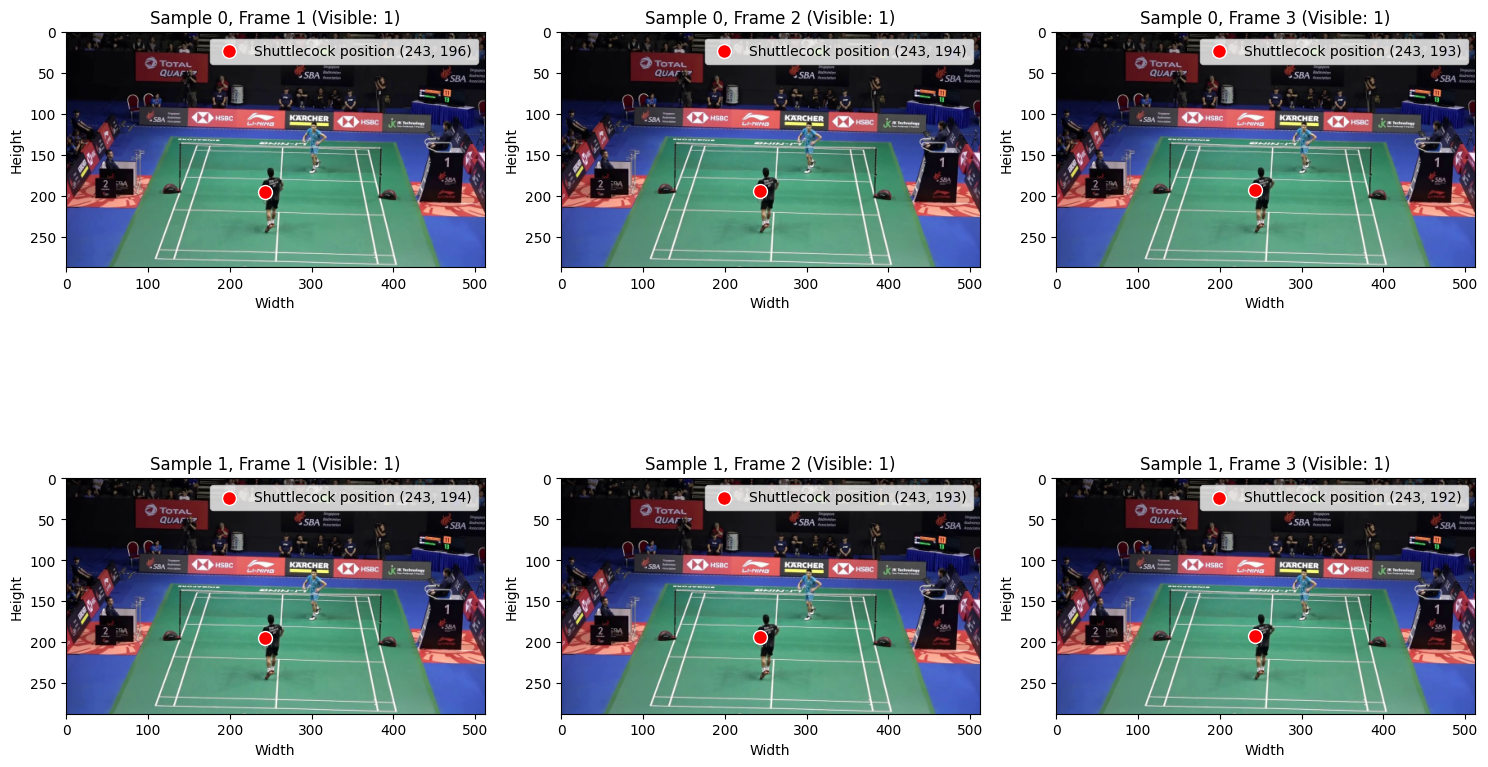

In [102]:
import math

cols = 3
num_samples_to_fetch = 2
total_frames_to_plot = num_samples_to_fetch * 3
rows = math.ceil(total_frames_to_plot / cols)
plt.figure(figsize=(cols * 5, rows * 5))

frame_counter = 0
for sample_idx in range(num_samples_to_fetch):
    if sample_idx >= len(dataset):
        print(f"Warning: Dataset only has {len(dataset)} samples. Plotting fewer than requested.")
        break

    images_from_sample, labels_from_sample = dataset[sample_idx]

    for i in range(3):
        if frame_counter >= total_frames_to_plot:
            break

        img_to_show = images_from_sample[i*3:(i*3)+3].permute(1, 2, 0).numpy()
        visibility, x, y = labels_from_sample[i].tolist()

        plt.subplot(rows, cols, frame_counter + 1)
        plt.imshow(img_to_show)
        plt.title(f"Sample {sample_idx}, Frame {i+1} (Visible: {int(visibility)})")
        plt.xlabel("Width")
        plt.ylabel("Height")


        if visibility == 1:
            plt.scatter(x, y, color='red', marker='o', s=100, edgecolors='white', linewidth=1, label=f'Shuttlecock position ({int(x)}, {int(y)})')
            plt.legend(loc='upper right')

        frame_counter += 1
    if frame_counter >= total_frames_to_plot:
        break

plt.tight_layout()
plt.show()

Generate Gaussian Heatmaps for Ball Position

In [103]:
HEATMAP_SIGMA = 5

def generate_heatmap(x, y, visibility, H, W, sigma=HEATMAP_SIGMA):
    if not visibility:
        return np.zeros((H, W), dtype=np.float32)

    cols, rows = np.meshgrid(np.arange(W), np.arange(H))
    heatmap = np.exp(-((cols - x) ** 2 + (rows - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)

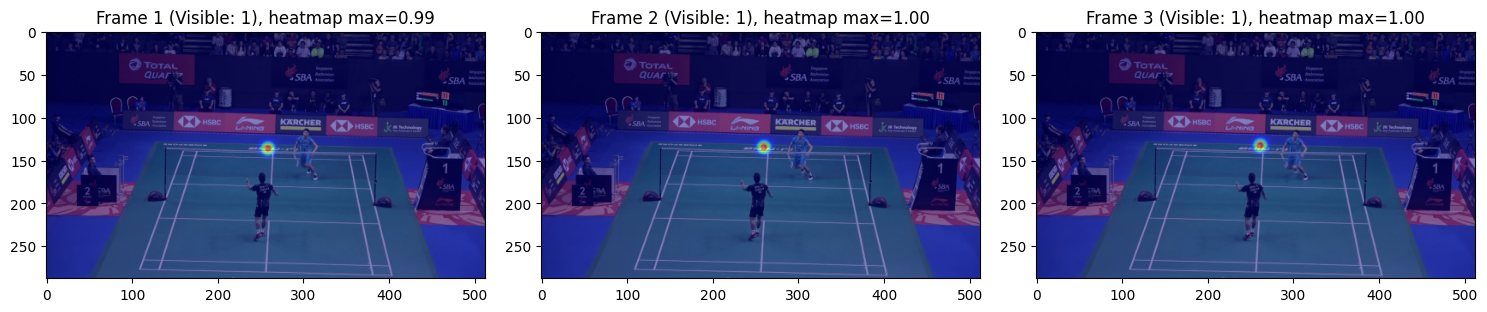

In [104]:
images, labels = dataset[15]
H, W = dataset.resize_to[1], dataset.resize_to[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    visibility, x, y = labels[i].tolist()
    heatmap = generate_heatmap(x, y, visibility, H, W)

    img_to_show = images[i*3:(i*3)+3].permute(1, 2, 0).numpy()
    ax.imshow(img_to_show)
    ax.imshow(heatmap, cmap='jet', alpha=0.5)
    ax.set_title(f"Frame {i+1} (Visible: {int(visibility)}), heatmap max={heatmap.max():.2f}")

plt.tight_layout()
plt.show()

VGG-Style Encoder-Decoder (TrackNetV2)

In [105]:
class TrackNetV2(nn.Module):
    def __init__(self):
        super().__init__()

        # ---- Encoder ----
        # Each block split into conv-layers and pool separately,
        # so we can grab the pre-pool output for skip connections.
        self.enc1_conv = nn.Sequential(
            nn.Conv2d(9, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2, 2)

        self.enc2_conv = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2, 2)

        self.enc3_conv = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2, 2)

        self.enc4_conv = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool4 = nn.MaxPool2d(2, 2)

        # ---- Decoder ----
        # dec*_conv in_channels = upsampled channels + concatenated skip channels
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1_conv = nn.Sequential(
            nn.Conv2d(768, 256, 3, padding=1), nn.ReLU(inplace=True),  # 256 (up1) + 512 (e4 skip)
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2_conv = nn.Sequential(
            nn.Conv2d(384, 128, 3, padding=1), nn.ReLU(inplace=True),  # 128 (up2) + 256 (e3 skip)
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
        )

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3_conv = nn.Sequential(
            nn.Conv2d(192, 64, 3, padding=1), nn.ReLU(inplace=True),  # 64 (up3) + 128 (e2 skip)
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
        )

        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        # Raw logits — no activation. Loss is BCEWithLogitsLoss, which applies
        # sigmoid internally (more numerically stable than a separate Sigmoid + BCE).
        self.final_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        # Encoder — keep pre-pool outputs for skip connections
        e1 = self.enc1_conv(x)          # (64, 288, 512)
        p1 = self.pool1(e1)             # (64, 144, 256)

        e2 = self.enc2_conv(p1)         # (128, 144, 256)
        p2 = self.pool2(e2)             # (128, 72, 128)

        e3 = self.enc3_conv(p2)         # (256, 72, 128)
        p3 = self.pool3(e3)             # (256, 36, 64)

        e4 = self.enc4_conv(p3)         # (512, 36, 64)
        p4 = self.pool4(e4)             # (512, 18, 32)  <- bottleneck

        # Decoder — upsample, concat with matching skip, conv
        d1 = self.up1(p4)                          # (256, 36, 64)
        d1 = torch.cat([d1, e4], dim=1)             # (768, 36, 64)
        d1 = self.dec1_conv(d1)                     # (256, 36, 64)

        d2 = self.up2(d1)                           # (128, 72, 128)
        d2 = torch.cat([d2, e3], dim=1)             # (384, 72, 128)
        d2 = self.dec2_conv(d2)                     # (128, 72, 128)

        d3 = self.up3(d2)                           # (64, 144, 256)
        d3 = torch.cat([d3, e2], dim=1)             # (192, 144, 256)
        d3 = self.dec3_conv(d3)                     # (64, 144, 256)

        d4 = self.up4(d3)                           # (32, 288, 512)
        out = self.final_conv(d4)                   # (3, 288, 512) raw logits

        return out

Heatmap Target Wrapper — pairs each triplet's images with its 3-channel Gaussian heatmap target

In [106]:
class TrackNetHeatmapDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.W, self.H = base_dataset.resize_to

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        images, labels = self.base_dataset[idx]

        heatmaps = np.stack([
            generate_heatmap(x=labels[i, 1].item(), y=labels[i, 2].item(),
                              visibility=labels[i, 0].item(), H=self.H, W=self.W)
            for i in range(labels.shape[0])
        ], axis=0)

        return images.float(), torch.from_numpy(heatmaps)


heatmap_dataset = TrackNetHeatmapDataset(dataset)
sample_images, sample_targets = heatmap_dataset[15]
print(f"Images shape:  {sample_images.shape}")
print(f"Targets shape: {sample_targets.shape}, max={sample_targets.max():.2f}")

Images shape:  torch.Size([9, 288, 512])
Targets shape: torch.Size([3, 288, 512]), max=1.00


Model, Weighted BCE Loss, Optimizer, Tiny Overfit Subset

In [107]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TrackNetV2().to(DEVICE)

# Gaussian blobs (sigma=5) cover a small fraction of the 288x512 frame, so
# background pixels vastly outnumber ball pixels. pos_weight upweights the
# positive term of BCE to counter that imbalance. BCEWithLogitsLoss works
# fine against our continuous 0->1 Gaussian targets, not just hard 0/1 labels.
POS_WEIGHT = 10.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Tiny subset to sanity-check the model/loss/optimizer can overfit before
# committing to a full training run.
subset_indices = list(range(15, 30))
train_subset = torch.utils.data.Subset(heatmap_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=4, shuffle=True)

print(f"Device: {DEVICE}")
print(f"Subset size: {len(train_subset)}")

Device: cuda
Subset size: 15


In [108]:
print(model.final_conv)

Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))


Training Loop — Overfit Sanity Check on the Tiny Subset

In [109]:
NUM_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 5

best_loss = float('inf')
patience_counter = 0

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {avg_epoch_loss:.4f}")

    # Early stopping logic
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter > EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after {epoch + 1} epochs due to no improvement in loss for {EARLY_STOPPING_PATIENCE} consecutive epochs.")
        break

Epoch 1/200 - Loss: 0.6743
Epoch 2/200 - Loss: 0.2733
Epoch 3/200 - Loss: 0.1213
Epoch 4/200 - Loss: 0.0860
Epoch 5/200 - Loss: 0.0703
Epoch 6/200 - Loss: 0.0594
Epoch 7/200 - Loss: 0.0557
Epoch 8/200 - Loss: 0.0520
Epoch 9/200 - Loss: 0.0501
Epoch 10/200 - Loss: 0.0483
Epoch 11/200 - Loss: 0.0448
Epoch 12/200 - Loss: 0.0419
Epoch 13/200 - Loss: 0.0387
Epoch 14/200 - Loss: 0.0329
Epoch 15/200 - Loss: 0.0448
Epoch 16/200 - Loss: 0.0317
Epoch 17/200 - Loss: 0.0155
Epoch 18/200 - Loss: 0.0146
Epoch 19/200 - Loss: 0.0192
Epoch 20/200 - Loss: 0.0200
Epoch 21/200 - Loss: 0.0155
Epoch 22/200 - Loss: 0.0128
Epoch 23/200 - Loss: 0.0115
Epoch 24/200 - Loss: 0.0108
Epoch 25/200 - Loss: 0.0101
Epoch 26/200 - Loss: 0.0092
Epoch 27/200 - Loss: 0.0092
Epoch 28/200 - Loss: 0.0089
Epoch 29/200 - Loss: 0.0088
Epoch 30/200 - Loss: 0.0087
Epoch 31/200 - Loss: 0.0087
Epoch 32/200 - Loss: 0.0090
Epoch 33/200 - Loss: 0.0086
Epoch 34/200 - Loss: 0.0093
Epoch 35/200 - Loss: 0.0091
Epoch 36/200 - Loss: 0.0092
E

In [110]:
model = TrackNetV2().to(DEVICE)
x = torch.randn(1, 9, 288, 512).to(DEVICE)
out = model(x)
print(out.shape)

torch.Size([1, 3, 288, 512])


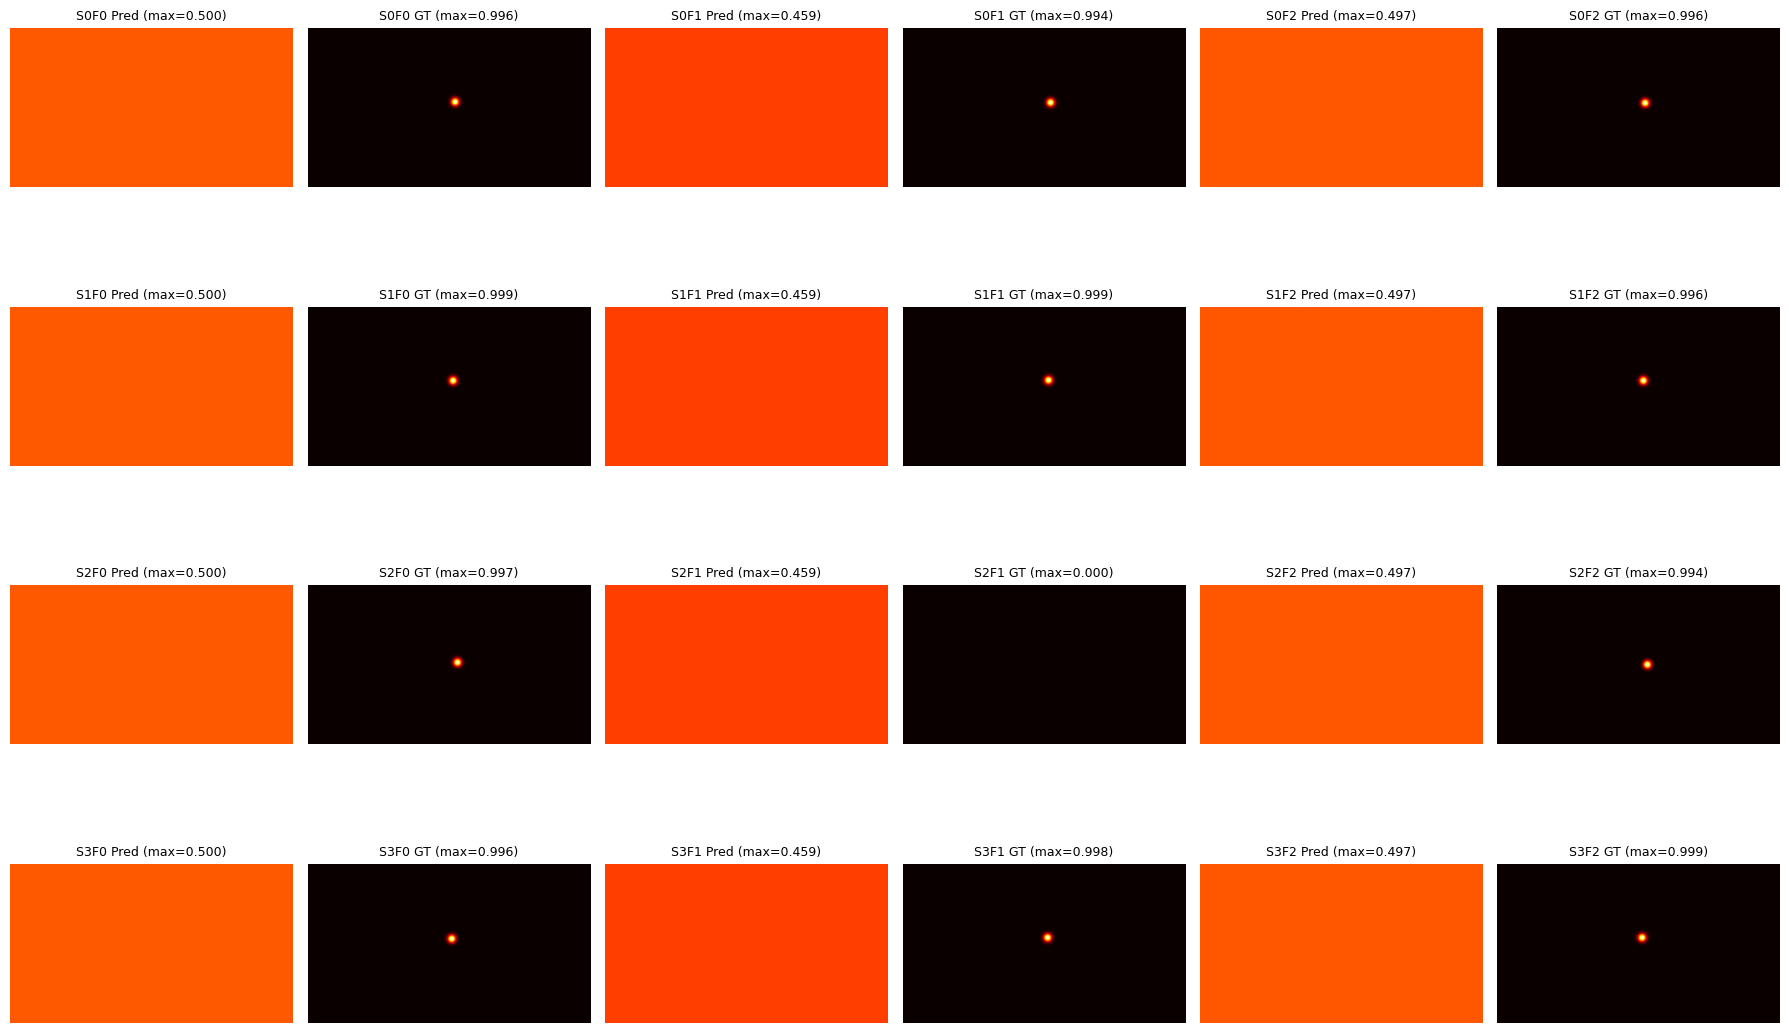

In [111]:
model.eval()
with torch.no_grad():
    images, targets = next(iter(train_loader))
    images = images.to(DEVICE)
    logits = model(images)
    preds = torch.sigmoid(logits)  # apply sigmoid manually now, since it's not in the model anymore

n_samples = preds.shape[0]
n_frames = preds.shape[1]

fig, axes = plt.subplots(n_samples, n_frames * 2, figsize=(n_frames * 2 * 3, n_samples * 3))

for s in range(n_samples):
    for f in range(n_frames):
        pred_heatmap = preds[s, f].cpu().numpy()
        target_heatmap = targets[s, f].cpu().numpy()

        ax_pred = axes[s, f * 2]
        ax_gt = axes[s, f * 2 + 1]

        ax_pred.imshow(pred_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_pred.set_title(f"S{s}F{f} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        ax_pred.axis('off')

        ax_gt.imshow(target_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_gt.set_title(f"S{s}F{f} GT (max={target_heatmap.max():.3f})", fontsize=9)
        ax_gt.axis('off')

plt.tight_layout()
plt.show()

In [112]:
model.eval()
with torch.no_grad():
    images, targets = next(iter(train_loader))
    images = images.to(DEVICE)
    targets = targets.to(DEVICE)
    logits = model(images)
    preds = torch.sigmoid(logits)

print("=== Overall prediction stats ===")
print(f"mean={preds.mean().item():.6f}  std={preds.std().item():.6f}  "
      f"min={preds.min().item():.6f}  max={preds.max().item():.6f}")

print("\n=== Overall logit stats (pre-sigmoid) ===")
print(f"mean={logits.mean().item():.6f}  std={logits.std().item():.6f}  "
      f"min={logits.min().item():.6f}  max={logits.max().item():.6f}")

print("\n=== Per-sample, per-frame: pred-at-ball vs pred-background-mean ===")
for s in range(preds.shape[0]):
    for f in range(preds.shape[1]):
        t = targets[s, f]
        p = preds[s, f]
        gt_max = t.max().item()
        if gt_max > 0.5:
            iy, ix = np.unravel_index(t.argmax().cpu().numpy(), t.shape)
            pred_at_ball = p[iy, ix].item()
        else:
            pred_at_ball = float('nan')
        bg_mask = t < 0.01
        pred_bg_mean = p[bg_mask].mean().item()
        pred_bg_std = p[bg_mask].std().item()
        print(f"S{s}F{f}: gt_max={gt_max:.3f}  pred_at_ball={pred_at_ball:.4f}  "
              f"pred_bg_mean={pred_bg_mean:.4f}  pred_bg_std={pred_bg_std:.4f}")

recomputed_loss = criterion(logits, targets)
print(f"\nRecomputed BCEWithLogitsLoss on this exact live batch: {recomputed_loss.item():.6f}")

# manual sanity-check of BCEWithLogits math on the background-only region, no pos_weight involved
bg_mask_full = targets < 0.01
manual_bg_loss = torch.nn.functional.binary_cross_entropy_with_logits(
    logits[bg_mask_full], targets[bg_mask_full], reduction='mean'
)
print(f"Manual BCE loss restricted to background-only pixels: {manual_bg_loss.item():.6f}")
print(f"Fraction of pixels counted as background (target<0.01): {bg_mask_full.float().mean().item():.6f}")


=== Overall prediction stats ===
mean=0.484360  std=0.018490  min=0.457059  max=0.499666

=== Overall logit stats (pre-sigmoid) ===
mean=-0.062690  std=0.074144  min=-0.172187  max=-0.001337

=== Per-sample, per-frame: pred-at-ball vs pred-background-mean ===
S0F0: gt_max=0.997  pred_at_ball=0.4992  pred_bg_mean=0.4991  pred_bg_std=0.0003
S0F1: gt_max=0.000  pred_at_ball=nan  pred_bg_mean=0.4583  pred_bg_std=0.0007
S0F2: gt_max=0.994  pred_at_ball=0.4938  pred_bg_mean=0.4957  pred_bg_std=0.0012
S1F0: gt_max=0.994  pred_at_ball=0.4992  pred_bg_mean=0.4991  pred_bg_std=0.0003
S1F1: gt_max=0.000  pred_at_ball=nan  pred_bg_mean=0.4583  pred_bg_std=0.0007
S1F2: gt_max=0.994  pred_at_ball=0.4937  pred_bg_mean=0.4957  pred_bg_std=0.0012
S2F0: gt_max=0.996  pred_at_ball=0.4990  pred_bg_mean=0.4991  pred_bg_std=0.0003
S2F1: gt_max=0.996  pred_at_ball=0.4584  pred_bg_mean=0.4583  pred_bg_std=0.0007
S2F2: gt_max=0.994  pred_at_ball=0.4939  pred_bg_mean=0.4957  pred_bg_std=0.0012
S3F0: gt_max=0.99

Total dataset size: 90255
Probing indices spread across full dataset: [0, 12893, 25786, 38680, 51573, 64467, 77360, 90254]


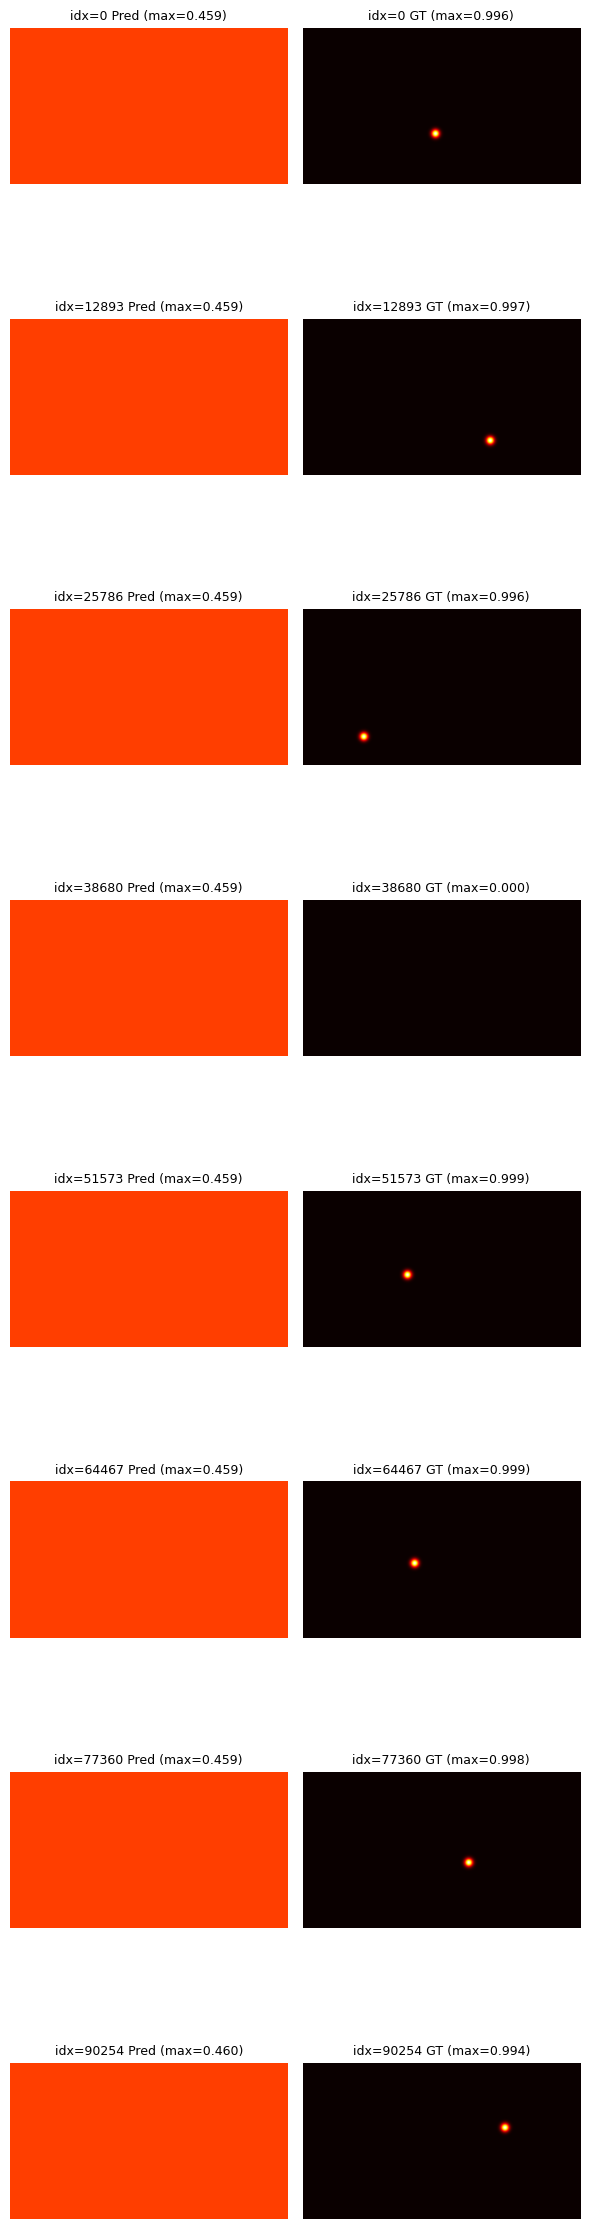

In [113]:
print(f"Total dataset size: {len(heatmap_dataset)}")

n_probe = 8
probe_indices = np.linspace(0, len(heatmap_dataset) - 1, n_probe).astype(int).tolist()
print(f"Probing indices spread across full dataset: {probe_indices}")

frame_idx = 1  # middle frame of each triplet

model.eval()
fig, axes = plt.subplots(n_probe, 2, figsize=(6, n_probe * 3))

with torch.no_grad():
    for row, idx in enumerate(probe_indices):
        images, targets = heatmap_dataset[idx]
        images = images.unsqueeze(0).to(DEVICE)
        logits = model(images)
        preds = torch.sigmoid(logits)

        pred_heatmap = preds[0, frame_idx].cpu().numpy()
        target_heatmap = targets[frame_idx].numpy()

        ax_pred = axes[row, 0]
        ax_gt = axes[row, 1]

        ax_pred.imshow(pred_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_pred.set_title(f"idx={idx} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        ax_pred.axis('off')

        ax_gt.imshow(target_heatmap, cmap='hot', vmin=0, vmax=1)
        ax_gt.set_title(f"idx={idx} GT (max={target_heatmap.max():.3f})", fontsize=9)
        ax_gt.axis('off')

plt.tight_layout()
plt.show()

IndexError: index 1 is out of bounds for dimension 0 with size 1

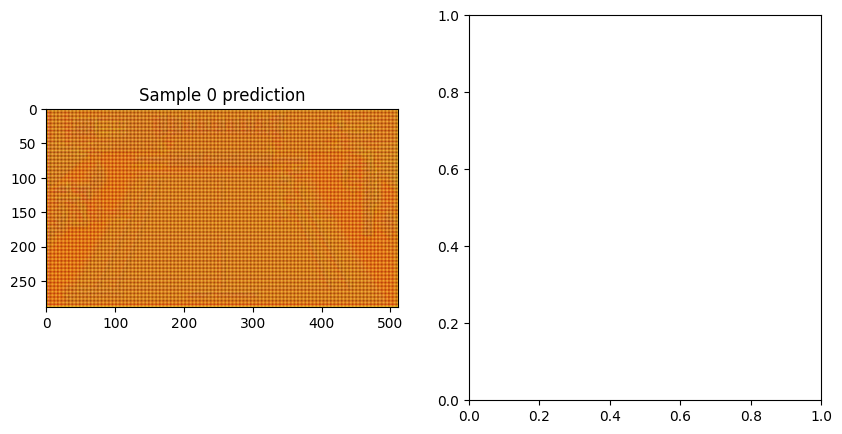

In [114]:
model.eval()
with torch.no_grad():
    logits = model(images)  # your same tiny batch
    preds = torch.sigmoid(logits)

# compare predicted heatmaps for sample 0 vs sample 1 (different ball locations)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(preds[0, 1].cpu().numpy(), cmap='hot')
axes[0].set_title("Sample 0 prediction")
axes[1].imshow(preds[1, 1].cpu().numpy(), cmap='hot')
axes[1].set_title("Sample 1 prediction")
plt.show()

## Real Training — Diverse Multi-Clip Subset (Train/Val Split by Clip)

The overfit sanity check above only ever saw 15 consecutive frames from one clip, which is why it failed to generalize. This section splits the full dataset by *clip* (not by frame) so train and validation never share a video, samples a diverse subset across many clips, and trains/evaluates properly.

In [115]:
import random

def get_clip_id(sample):
    frame_path_1 = sample[0]
    return os.path.normpath(os.path.dirname(frame_path_1))

clip_ids = [get_clip_id(s) for s in samples]
unique_clips = sorted(set(clip_ids))
print(f"Total samples: {len(samples)}, unique clips: {len(unique_clips)}")

rng = random.Random(42)
shuffled_clips = unique_clips[:]
rng.shuffle(shuffled_clips)

VAL_FRACTION = 0.2
n_val_clips = max(1, int(len(shuffled_clips) * VAL_FRACTION))
val_clips = set(shuffled_clips[:n_val_clips])
train_clips = set(shuffled_clips[n_val_clips:])

train_indices_all = [i for i, cid in enumerate(clip_ids) if cid in train_clips]
val_indices_all = [i for i, cid in enumerate(clip_ids) if cid in val_clips]

print(f"Train clips: {len(train_clips)}, samples available: {len(train_indices_all)}")
print(f"Val clips:   {len(val_clips)}, samples available: {len(val_indices_all)}")

N_TRAIN = 600
N_VAL = 150
rng.shuffle(train_indices_all)
rng.shuffle(val_indices_all)
train_indices = train_indices_all[:N_TRAIN]
val_indices = val_indices_all[:N_VAL]

print(f"\nUsing {len(train_indices)} train samples from "
      f"{len(set(clip_ids[i] for i in train_indices))} distinct clips")
print(f"Using {len(val_indices)} val samples from "
      f"{len(set(clip_ids[i] for i in val_indices))} distinct clips (held out, no overlap with train clips)")

BATCH_SIZE = 8
train_subset_full = torch.utils.data.Subset(heatmap_dataset, train_indices)
val_subset_full = torch.utils.data.Subset(heatmap_dataset, val_indices)

full_train_loader = torch.utils.data.DataLoader(train_subset_full, batch_size=BATCH_SIZE, shuffle=True)
full_val_loader = torch.utils.data.DataLoader(val_subset_full, batch_size=BATCH_SIZE, shuffle=False)

Total samples: 90255, unique clips: 201
Train clips: 161, samples available: 73879
Val clips:   40, samples available: 16376

Using 600 train samples from 149 distinct clips
Using 150 val samples from 38 distinct clips (held out, no overlap with train clips)


In [116]:
# Fresh model + optimizer + criterion, created together in one cell so the
# optimizer can never end up bound to a stale/orphaned model instance.
model = TrackNetV2().to(DEVICE)
POS_WEIGHT = 10.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print("Fresh model/optimizer/criterion created together.")

Fresh model/optimizer/criterion created together.


In [117]:
import sys
names = ["model", "optimizer", "criterion", "full_train_loader", "full_val_loader",
         "train_subset_full", "val_subset_full", "train_indices", "val_indices", "DEVICE"]
for n in names:
    print(n, "->", "OK" if n in globals() else "MISSING")
print("\nCUDA available:", torch.cuda.is_available())
print("Model device:", next(model.parameters()).device if "model" in globals() else "N/A")

model -> OK
optimizer -> OK
criterion -> OK
full_train_loader -> OK
full_val_loader -> OK
train_subset_full -> OK
val_subset_full -> OK
train_indices -> OK
val_indices -> OK
DEVICE -> OK

CUDA available: True
Model device: cuda:0


In [ ]:
NUM_EPOCHS = 12
history = {"train_loss": [], "val_loss": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, targets in full_train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_subset_full)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, targets in full_val_loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            val_running_loss += loss.item() * images.size(0)
    val_loss = val_running_loss / len(val_subset_full)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}")

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("BCEWithLogitsLoss")
plt.legend()
plt.title("Train vs held-out-clip val loss")
plt.show()

# Visualize predictions on held-out validation clips (never seen during training)
model.eval()
n_show = 8
show_indices = random.Random(123).sample(val_indices, min(n_show, len(val_indices)))
frame_idx = 1

fig, axes = plt.subplots(len(show_indices), 2, figsize=(6, len(show_indices) * 3))
with torch.no_grad():
    for row, idx in enumerate(show_indices):
        images, targets = heatmap_dataset[idx]
        images = images.unsqueeze(0).to(DEVICE)
        logits = model(images)
        preds = torch.sigmoid(logits)

        pred_heatmap = preds[0, frame_idx].cpu().numpy()
        target_heatmap = targets[frame_idx].numpy()

        axes[row, 0].imshow(pred_heatmap, cmap='hot', vmin=0, vmax=1)
        axes[row, 0].set_title(f"val idx={idx} Pred (max={pred_heatmap.max():.3f})", fontsize=9)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(target_heatmap, cmap='hot', vmin=0, vmax=1)
        axes[row, 1].set_title(f"val idx={idx} GT (max={target_heatmap.max():.3f})", fontsize=9)
        axes[row, 1].axis('off')

plt.tight_layout()
plt.show()